# IVU Transverse Impedance Analysis

Analysis of two-bunch IVU transverse impedance measurements.

The workflow consists of:

1. Loading and preparing measurement data
2. Calculating bunch-to-bunch orbit differences
3. Inspecting orbit profiles
4. Calculating the IVU orbit response
5. Projecting the measured orbit onto the IVU response
6. Fitting the transverse kick factor
7. Visualizing the final results

In [69]:
import os

from impedance_analysis_class import ImpedanceIVUAnalysis

## 1. Measurement data

Define the measurement files and their corresponding vertical orbit
bumps. Each file represents one measurement configuration.

In [70]:
data_dir = os.path.join(
    "/mnt",
    "shared",
    "screens-iocs",
    "data_by_day",
    "2026-08-24-SI_IVU_impedance_measurement",
)

gaps = ['4p300mm']
bumps = ['m1000um', 'm0500um', 'p0000um', 'p0500um', 'p1000um']
y0_values = [-1.0, -0.5, 0.0, 0.5, 1.0]  # [mm]

file_paths = [
    os.path.join(
        data_dir,
        (
        f"ivu_08_gap_{gap}_bump_y_{bump}_"
        "yp_p0000urad_acq_n0.pickle"
        ),
    )
    for gap in gaps
    for bump in bumps
]

y0_of_files = [
    y0
    for gap in gaps
    for y0 in y0_values
]

## 2. Analysis initialization and data preparation

Load the selected measurement configurations, assign their vertical
bump values, and prepare the data for analysis.

Data preparation includes:

- calculation of bunch currents and charges
- joining odd/even BPM acquisition groups, when applicable
- creation of the configuration table

In [88]:
analysis = ImpedanceIVUAnalysis()

analysis.load_data(
    file_paths,
    y0 = y0_of_files,
)

analysis.prepare_data()

analysis.set_spos_bpms();

## 3. Bunch-to-bunch orbit differences

Calculate the vertical orbit difference between the two bunches:

\begin{equation}
\Delta y = y_1 - y_2
\end{equation}

For each configuration, the resulting array has shape:

\begin{equation}
(n_{\mathrm{acq}}, n_{\mathrm{BPM}}, n_{\mathrm{turns}})
\end{equation}

In [87]:
analysis.calculate_delta_orbit(
    plane="y",
)

analysis.calculate_delta_orbit_stats(
    plane="y",
);

### 3.1 Raw and charge-normalized orbit data

Access the full orbit arrays and their processed statistics. The
normalized quantities are divided by the mean bunch charge difference
of each configuration.

In [73]:
delta_y = analysis.get_delta_orbit(
    plane="y",
    normalized=False,
)

delta_y_norm = analysis.get_delta_orbit(
    plane="y",
    normalized=True,
)

stats_y = analysis.get_delta_orbit_stats(
    plane="y",
    normalized=False,
)

stats_y_norm = analysis.get_delta_orbit_stats(
    plane="y",
    normalized=True,
)

Verify the dimensions of the raw, normalized, and processed results for
one measurement configuration.

In [74]:
config_to_check = 1

print(
    "Raw orbit shape: ",
    delta_y[config_to_check].shape,
)
print(
    "Normalized orbit shape:",
    delta_y_norm[config_to_check].shape,
)
print(
    "Normalized mean shape: ",
    stats_y_norm["mean"][config_to_check].shape,
)
print(
    "Normalized SEM shape: ",
    stats_y_norm["sem"][config_to_check].shape,
)
print(
    "Number of samples: ",
    stats_y["n_samples"][config_to_check],
)

Raw orbit shape:  (5, 160, 500)
Normalized orbit shape: (5, 160, 500)
Normalized mean shape:  (160,)
Normalized SEM shape:  (160,)
Number of samples:  2500


## 4. Orbit-profile visualization

### 4.1 Acquisition repeatability

Compare the turn-averaged orbit-difference profiles obtained from the
individual acquisitions of one configuration.

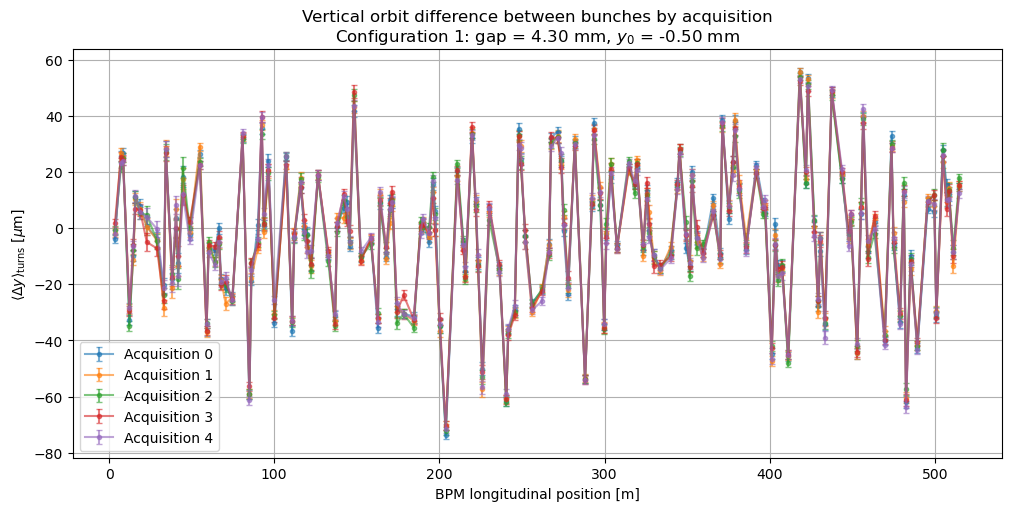

In [75]:
fig, ax = analysis.plot_acquisition_means(
    cfg=1,
    plane="y",
    error="sem",
)

### 4.2 Configuration mean profiles

Compare the mean orbit-difference profiles obtained for the different
vertical orbit bumps.

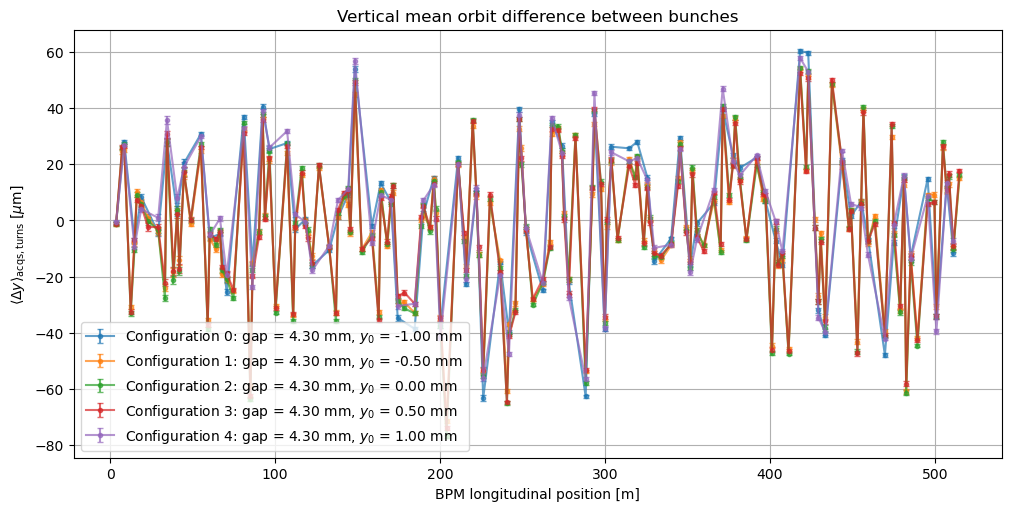

In [76]:
fig, ax = analysis.plot_config_means(
    cfgs=range(len(file_paths)),
    plane="y",
    error="sem",
)

### 4.3 Reference-subtracted orbit shifts

Compare selected configurations relative to the zero-bump
configuration. Charge normalization accounts for differences in the
measured bunch charge imbalance.

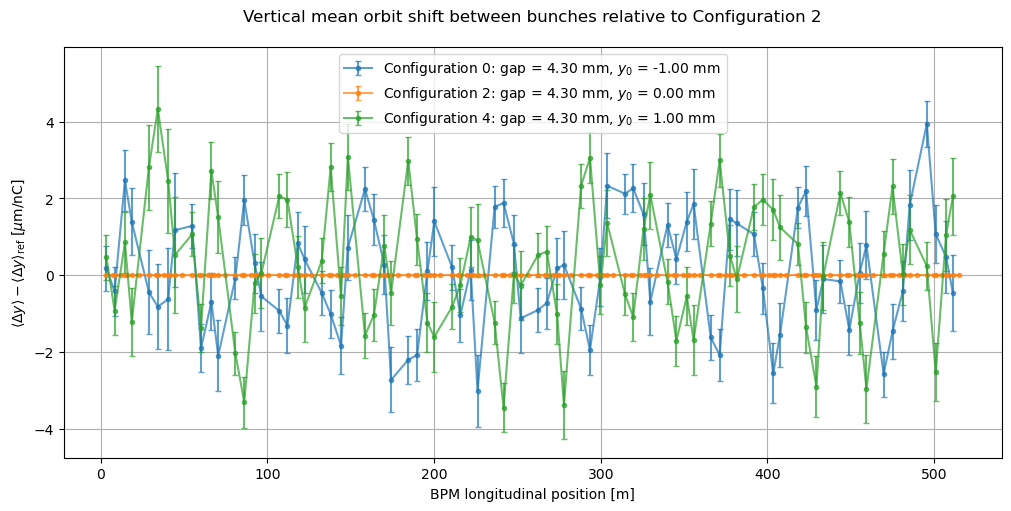

In [77]:
ref_cfg = 2
fig, ax = analysis.plot_config_means(
    cfgs=[0, 2, 4],
    ref_cfg=ref_cfg,
    plane="y",
    normalized=True,
    error="sem",
)

## 5. IVU orbit response

Calculate the IVU orbit response column using the accelerator model.
The full response contains the horizontal response followed by the
vertical response.

The selected vertical response is then adapted to the global BPM
indices used by each measurement configuration.

In [86]:
resp_mat, resp_info = analysis.calc_ivu_respmat(
    delta_vkick=5e-6,
    ivu_number=1,
)

M_ivu_y = analysis.set_ivu_respmat(plane="y")

Checking dimensions.

In [79]:
print(analysis.resp_mat.shape)
print(analysis.M_ivu['y'][1].shape)

(320,)
(160,)


## 6. Kick-angle projection

Project the mean orbit-difference profile of each configuration onto
the corresponding IVU response vector:

\begin{equation}
\Delta y = \theta M_{\mathrm{IVU}}
\end{equation}

The projection is performed using the orbit SEM as the BPM uncertainty.

In [80]:
theta_fit_y = analysis.fit_theta(
plane="y",
error="sem",
)

## 7. Transverse kick-factor fit

For all configurations measured at the selected gap, fit:

\begin{equation}
\frac{\theta}{\Delta q} = b + a y_0
\end{equation}

The transverse kick factor is calculated from the fitted slope \(a\).

In [81]:
gap_to_fit = 4.3  # [mm]

kperp_fit = analysis.fit_kperp(
    gap=gap_to_fit,
    plane="y",
)

Results:

In [82]:
print(
    f"kperp = {kperp_fit['kperp']:.3f} +/- "
    f"{kperp_fit['kperp_err']:.3f} V/(pC m)"
)

print(
    f"slope = {kperp_fit['a']:.4e} +/- "
    f"{kperp_fit['a_err']:.4e} "
    "urad/(nC mm)"
)

print(
    f"reduced chi2 = "
    f"{kperp_fit['reduced_chi2']:.3f}"
)

kperp = 651.667 +/- 17.474 V/(pC m)
slope = 2.1722e-01 +/- 5.8248e-03 urad/(nC mm)
reduced chi2 = 2.456


## 8. Final result visualization

### 8.1 Kick angle versus vertical orbit bump

Display the charge-normalized projected kick angles and the weighted
linear fit used to obtain the kick factor.

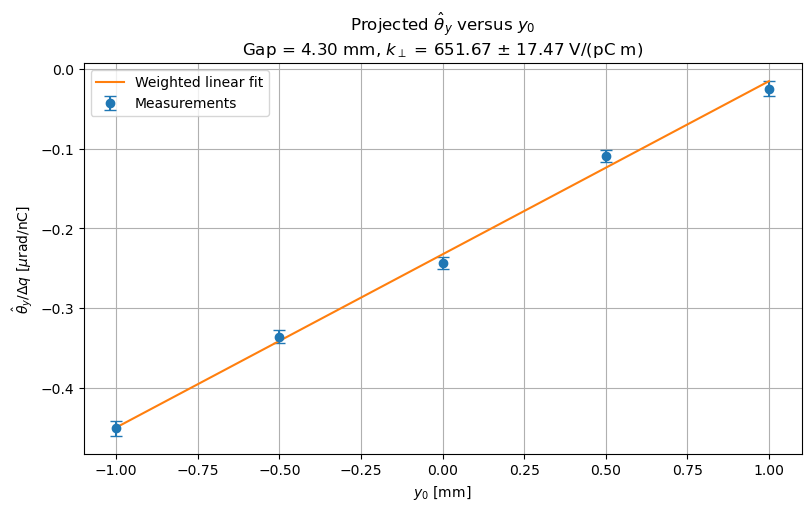

In [83]:
fig, ax = analysis.plot_theta_fit(
    gap=gap_to_fit,
    plane="y",
    normalized=True,
)

### 8.2 Individual-theta orbit projection

Compare the reference-subtracted measured orbit with the model obtained
from the independently projected kick angles of the selected and
reference configurations.

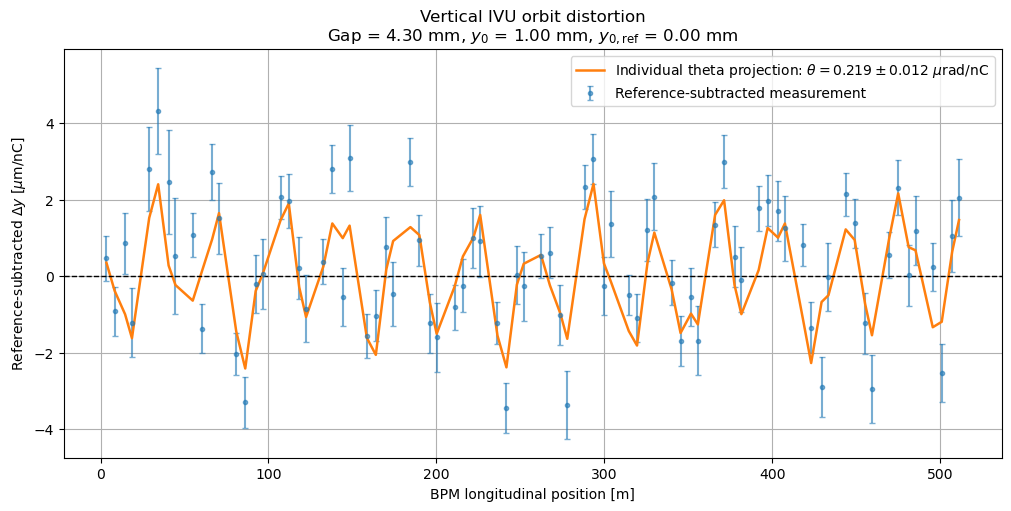

In [84]:
cfg_to_plot = 4
ref_cfg = 2

fig, ax = analysis.plot_ivu_projection(
    cfg=cfg_to_plot,
    ref_cfg=ref_cfg,
    plane="y",
    normalized=True,
    model="individual",
)

### 8.3 Global kick-factor orbit projection

Compare the reference-subtracted measured orbit with the prediction
obtained from the common kick-factor fit at the selected gap.

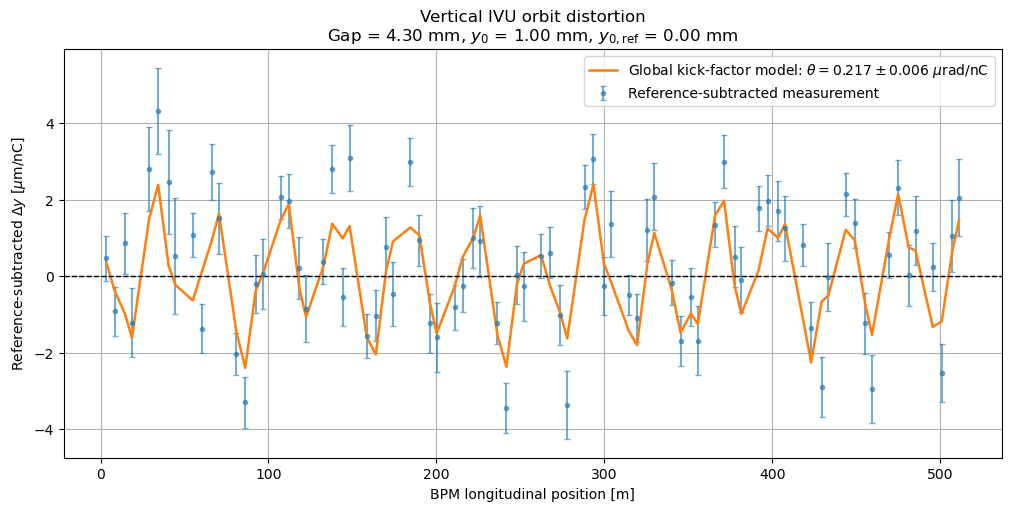

In [85]:
fig, ax = analysis.plot_ivu_projection(
    cfg=cfg_to_plot,
    ref_cfg=ref_cfg,
    plane="y",
    normalized=True,
    model="global",
)

### 8.4 Kick factor versus IVU gap

Display all kick-factor fits currently stored in the analysis object.

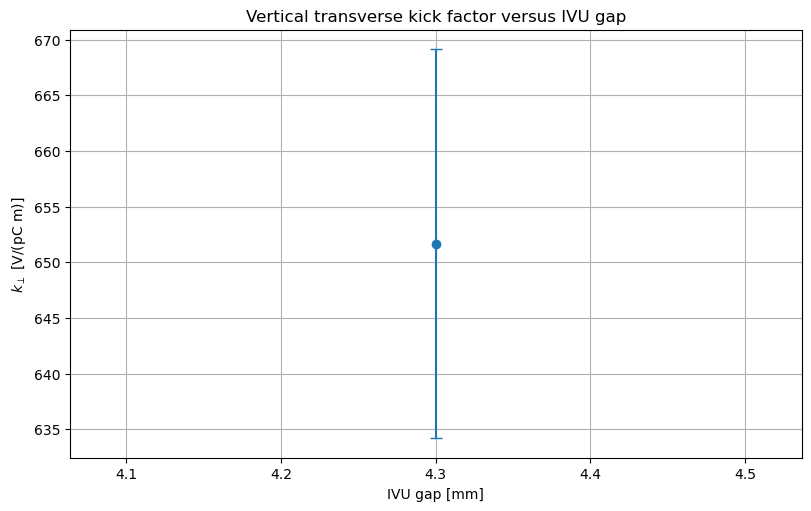

In [65]:
fig, ax = analysis.plot_kperp_vs_gap(
    plane="y",
)